In [3]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np

In [4]:
fashion_mnist=keras.datasets.fashion_mnist
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist.load_data()

print(X_train_full.shape)
print(X_train_full.dtype)

(60000, 28, 28)
uint8


In [5]:
X_valid,X_train=X_train_full[:5000]/255.0,X_train_full[5000:]/255.0
y_valid,y_train=y_train_full[:5000],y_train_full[5000:]

class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [6]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(300,kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100,kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10,activation='softmax')
])

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,210 (1.02 MB)

 Trainable params: 267,410 (1.02 MB)

 Non-trainable params: 800 (3.12 KB)

In [7]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [8]:
history=model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7964 - loss: 0.6068 - val_accuracy: 0.8550 - val_loss: 0.4208
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8505 - loss: 0.4273 - val_accuracy: 0.8746 - val_loss: 0.3604
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8658 - loss: 0.3800 - val_accuracy: 0.8742 - val_loss: 0.3619
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8740 - loss: 0.3535 - val_accuracy: 0.8814 - val_loss: 0.3411
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8809 - loss: 0.3323 - val_accuracy: 0.8864 - val_loss: 0.3165
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8864 - loss: 0.3149 - val_accuracy: 0.8858 - val_loss: 0.3205
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8934 - loss: 0.2978 - val_accuracy: 0.8914 - val_loss: 0.3086
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8979 - loss: 0.2852 - 

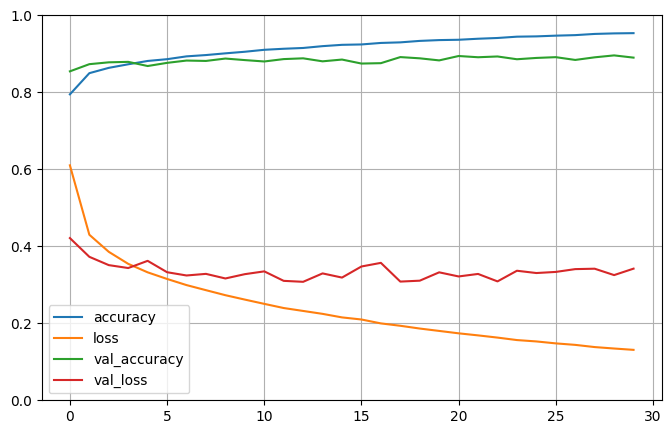

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) # vertical range to [0,1]
plt.show()

Vanishing and exploding gradients.

This is a common problem in training deep neural netwokrs. The problem occurs in back propagation when gradients are propageted back by multiplying them with the weights of each layer, If the weights are very small that means smaller than 1 , the gradient will get smaller and smaller and eventually it will vanish to zero as it reaches the earlier laye. This means that the weights in the earlier layers will not get updated and the network will not learn properly.

On the other hand if the weights are bigger then multiplier will get bigger and bigger and it will explode to infinity as it reaches the eralier layers . This will cause the weights to get very large and the network will become unstable.

To mitigate that issue several techniques can be used such as:

1. Weight Initialization: Using proper weight initialization techniques such as Xavier or He initialization can help in maintaining the scale of the gradients.

exmaple:
```python
 kernel_initializer='he_normal' # for relu activation
 ```

2. Using Activation Functions ->  Using better activation functins other than relu such as leaky relu, ELu,swish can help in reducing the chances of vanishing gradients. They are less likely to saturate compared to traditional activation functions like sigmoid or tanh.

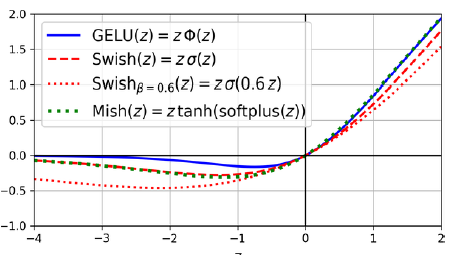

3. Batch Normalization: This technique normalizes the inputs of each layer, which helps in maintaining a stable distribution of activations and gradients throughout the network. We just add BachNormalization layer between the dense/convolution layer and activation layer.

4. Gradient Clipping: This technique involves setting a threshold value for gradients. If the gradients exceed this threshold, they are scaled down to prevent them from exploding.

Some Exmaple of Transfer Learning Models on MNIST Dataset.

In [2]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np

In [32]:
fashion_mnist=keras.datasets.fashion_mnist
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist.load_data()

print(X_train_full.shape)
print(X_train_full.dtype)
print(X_test.shape)

(60000, 28, 28)
uint8
(10000, 28, 28)


In [33]:
X_valid_A,X_valid_B,X_train_A,X_train_B=X_train_full[:5000]/255.0,X_train_full[5000:10000]/255.0,X_train_full[10000:55000]/255.0,X_train_full[55000:]/255.0
y_valid_A,y_valid_B,y_train_A,y_train_B=y_train_full[:5000],y_train_full[5000:10000],y_train_full[10000:55000],y_train_full[55000:]
X_test_A,X_test_B=X_test[:5000],X_test[5000:]
y_test_A,y_test_B=y_test[:5000],y_test[5000:]
class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [34]:
model = keras.models.Sequential([
keras.layers.Flatten(input_shape=[28, 28]),
keras.layers.Dense(300, activation="relu"),
keras.layers.Dense(100, activation="relu"),
keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
history=model.fit(X_train_A,y_train_A,epochs=30,validation_data=(X_valid_A,y_valid_B))

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7557 - loss: 0.7498 - val_accuracy: 0.1040 - val_loss: 6.8577
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8244 - loss: 0.5082 - val_accuracy: 0.1054 - val_loss: 7.5411
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8394 - loss: 0.4614 - val_accuracy: 0.1058 - val_loss: 8.0590
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8488 - loss: 0.4339 - val_accuracy: 0.1040 - val_loss: 8.4614
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8544 - loss: 0.4127 - val_accuracy: 0.1048 - val_loss: 8.4438
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8620 - loss: 0.3953 - val_accuracy: 0.1038 - val_loss: 8.7095
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8655 - loss: 0.3824 - val_accuracy: 0.1014 - val_loss: 8.8334
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8704 - loss: 0.3702 - 

In [36]:
model.save('my_model_A.h5')

In [37]:
model_A=tf.keras.models.load_model("my_model_A.h5")
model_B_on_A=tf.keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1,activation='sigmoid'))



Now model_A and model_B_on_A share some layers so if you modify the weights of model_A the weights of model_B_on_A will also be modified. To avoid this we can clone the model_A and create a new model with the same architecture and weights. To do tis you should use the following code:

```python
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())
````

this code copy only architecture so you need to set the weights manually using set_weights() method.

In [38]:
for layer in model_B_on_A.layers[:-1]: # we freez reused layers beceause when we train some new layers large erorr gradient my occur 
    layer.trainable=False              # and it will affect the reused layers weight and we want to avoid it by freezing them
optimizer=tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss='binary_crossentropy', optimizer=optimizer,metrics=['accuracy'])
# After freezing and unfreeze you must compile the model

In [39]:
history= model.fit(X_train_B,y_train_B, epochs=4, validation_data=(X_valid_B,y_valid_B))

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8748 - loss: 0.3363 - val_accuracy: 0.8672 - val_loss: 0.3576
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8852 - loss: 0.3111 - val_accuracy: 0.8824 - val_loss: 0.3399
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8876 - loss: 0.2970 - val_accuracy: 0.8678 - val_loss: 0.3725
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8924 - loss: 0.2826 - val_accuracy: 0.8850 - val_loss: 0.3156


In [40]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable=True

optimizer=keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history=model_B_on_A.fit(X_train_B,y_train_B,epochs=16,validation_data=(X_valid_B,y_valid_B))

Epoch 1/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1048 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 2/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 3/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 4/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 5/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 6/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 7/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 8/16
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1042 - loss: nan - val_accuracy: 0.0970 - val_loss: nan
Epoch 9/16
157/157 ━━━━━

In [42]:
model_B_on_A.evaluate(X_test_B,y_test_B)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0986 - loss: nan


[nan, 0.09860000014305115]

If you don't have enough labeld data for training the model you can gather unlabeled data and use it to do unsupervised pretraining using techniques such as autoencoders or self-supervised learning. After pretraining you can fine tune the model on your labeled data.

Other option is pretraining neural network on auxilary task that you can easily generate labeled data.

To speed up the trainig process of large neural netwokr you can use Faster Optimizers than gradient Desecent.

1. Momentum Optimizer: This optmizer adds a fraction of the previous update to the current update, which helps in accelerating convergence and reducing oscillations. If the gradients is small it will go slower but if the fradient is larger it will go faster. We have to set new pramterter called momentum that is form 0 to 1 usually set to 0.9.
```python
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
```

2. Nestrov Accelerated Gradient: It is a variant of momentum optimizer we that change that it measures the gradine slightly a head of cost function in direction of momentum beceause the vector of momentum points in the right direction, toward the optimum. It speeds up convergence even more than momentum optimizer.
```python
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
```

3. AdaGrad: This optimizer adapts the learning rate for each parameter based on the historical gradients. It gives larger updates to infrequent parameters and smaller updates to frequent parameters. This is useful for simple qudratic problems but it can lead to very small learning rates over time. So using it in deep learning is not recommended beceause it can stop to eraly before reaching the optimum.
```python
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.01)
```

4. RMSProp: This optimizer also adapts the learning rate for each parameter but it uses a moving average of squared gradients to normalize the gradients. This helps in maintaining a stable learning rate and prevents it from getting too small. It is well suited for non-stationary objectives and is commonly used in training deep neural networks.
```python
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)
```
5. Adam(adaptive moment estimation): This optimizer combines the benefits of both momentum and RMSProp. It maintains a moving average of both the gradients and the squared gradients, which helps in adapting the learning rate for each parameter. Adam is widely used in deep learning due to its efficiency and effectiveness.

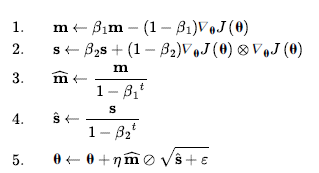

```python
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
``` 

COMPARISON OF OPTIMIZERS:

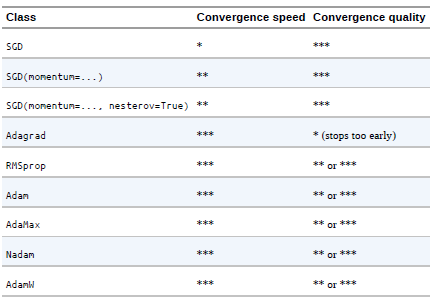

Learning rate scheduling:
Adjusting the learning rate during training can help in improving convergence and achieving better performance. Here are some common learning rate scheduling techniques:

1. Power scheduling : In this technique, the learning rate is decreased according to a power function of the epoch number. The learning rate at epoch t is given by:
   lr(t) = lr_0 / (1 + decay_rate * t)^power

2. Exponential Decay: In this technique, the learning rate is decreased exponentially over time. The learning rate at epoch t is given by:
   lr(t) = lr_0 * exp(-decay_rate * t)

Implementation in TensorFlow/Keras:
```python
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, decay=1e-4)

def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

```

history.history["lr"] gives you access to the list of learning rates used during training.

Regularization Techniques to prevent overfitting in Deep Neural Networks:

1. L1 and L2 Regularization: These techniques add a penalty term to the loss function based on the magnitude of the weights. L1 regularization adds the absolute values of the weights, while L2 regularization adds the squared values of the weights. This encourages the model to learn smaller weights, which can help in reducing overfitting.

```python
layer = tf.keras.layers.Dense(100, activation="relu",kernel_initializer="he_normal",
                                kernel_regularizer=tf.keras.regularizers.l2(0.01))
````

Since you want to apply the same regularization to all layers, you can create loop or use pythons functools.partial to create a custom layer with the desired regularization and then use it throughout your model.

In [4]:
from functools import partial

RegularizedDense=partial(tf.keras.layers.Dense,activation='relu',
                         kernel_initializer='he_normal',kernel_regularizer=tf.keras.regularizers.l2(0.01))

model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(100, activation='softmax')    
])

L2 reguralization is fine when tou use SGD with momentum or Nesterov Accelerated Gradient.
But with Adam optimizer L2 regularization is not effective because Adam already includes a form of adaptive regularization. Instead, you can use Weight Decay which is a more suitable regularization technique for Adam optimizer.

Dropout algorithm: This technique randomly drops some neurons during training with a certain probability (dropout rate) we exclude here output layer. This prevents the network from relying too much on specific neurons and encourages it to learn more robust features. During inference, all neurons are used, but their outputs are scaled down by the dropout rate to account for the missing neurons during training.

In practice you can apply dropout only the neurons in the top layers of the network since they are more likely to overfit compared to the lower layers that learn more general features.

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10,activation='softmax'),
])
#increase dropout rate f the model is overfitting and decrease if is underfitting

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Implementation of MC Dropout for Uncertainty Estimation:

In [13]:
import numpy as np
y_probas=np.stack([model(X_test,training=True) for sample in range(100)])
y_proba=y_probas.mean(axis=0) 

In [11]:
print(model.predict(X_test[:1]).round(3))
y_proba[0].round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

In [12]:
y_std=y_probas.std(axis=0)
y_std[0].round(3)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

Sample configuration that will work in most cases:

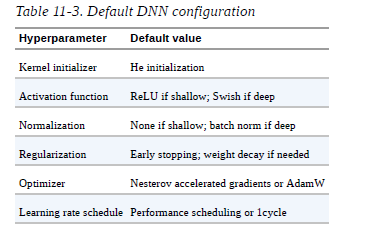

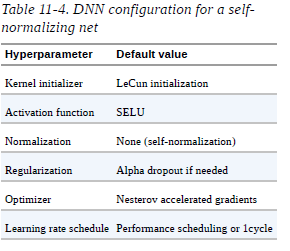